In [ ]:
# import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
#load data sets
import pandas as pd
df = pd.read_excel ("/content/Processed_Flipdata.xlsx")
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 50.8+ KB
None
   Unnamed: 0            Model        Colour  Memory  RAM  Battery_  \
0           0  Infinix SMART 7   Night Black      64    4      6000   
1           1  Infinix SMART 7    Azure Blue      64    4      6000  

In [ ]:
df.columns = df.columns.str.strip().str.replace(' ', '_')
if 'Unnamed:_0' in df.columns:
    df = df.drop(columns=['Unnamed:_0'])
print("Standardized and cleaned columns:", df.columns.tolist())

Standardized and cleaned columns: ['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear_Camera', 'Front_Camera', 'AI_Lens', 'Mobile_Height', 'Processor_', 'Prize']


In [ ]:
#identify categorical and numerical features
categorical_features = ['Model', 'Color', 'Processor', 'AI_lens']
numerical_features = ['RAM', 'Internal _Memory', 'Battery',
                      'Rear_Camera', 'Front_Camera', 'Mobile Height', 'Price']




In [ ]:
print("\nCategorical Features:", categorical_features)
print("Numerical Features:", numerical_features)



Categorical Features: ['Model', 'Color', 'Processor', 'AI_lens']
Numerical Features: ['RAM', 'Internal _Memory', 'Battery', 'Rear_Camera', 'Front_Camera', 'Mobile Height', 'Price']


In [ ]:
print("\nMissing Values:") #Check for missing values

print(df.isnull().sum())



Missing Values:
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear_Camera      0
Front_Camera     0
AI_Lens          0
Mobile_Height    0
Processor_       0
Prize            0
dtype: int64


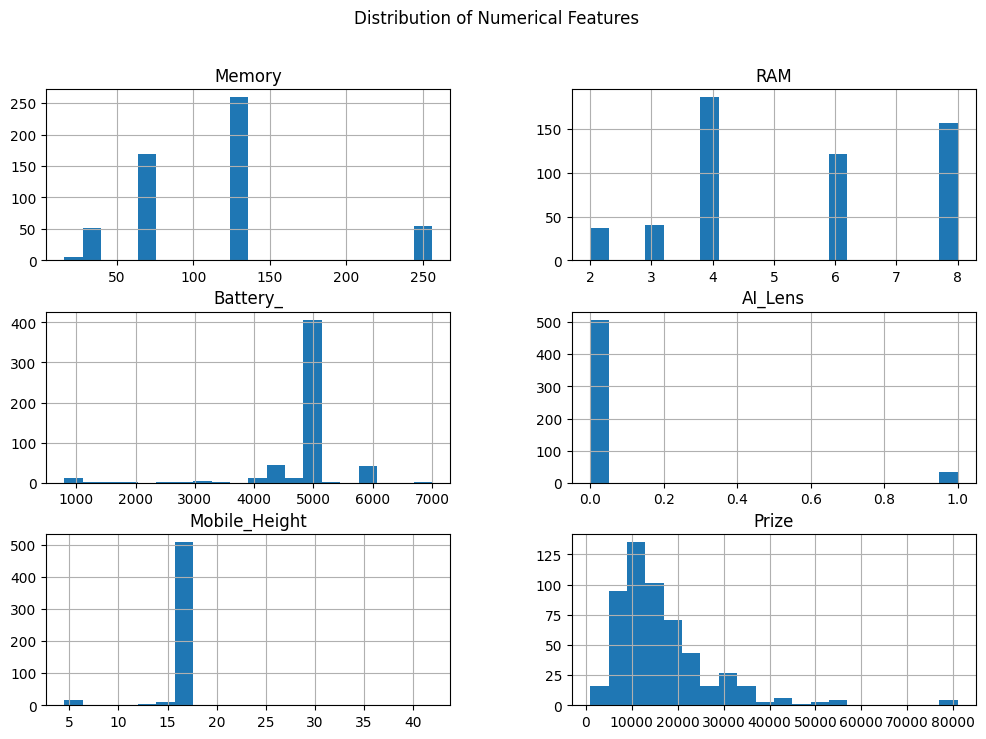

In [ ]:
# Histograms for numerical features
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms
df[numeric_cols].hist(bins=20, figsize=(12,8))
plt.suptitle("Distribution of Numerical Features")
plt.show()

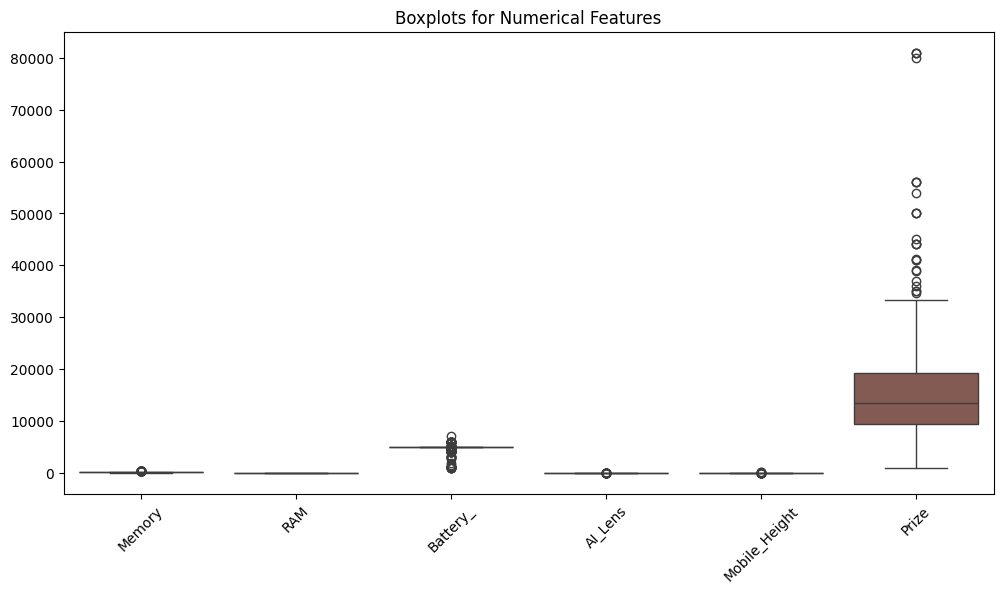

In [ ]:
plt.figure(figsize=(12,6)) #boxplot for numericals features
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplots for Numerical Features")
plt.xticks(rotation=45)
plt.show()

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numeric Columns:", numeric_cols)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:", categorical_cols)

Numeric Columns: ['Memory', 'RAM', 'Battery_', 'AI_Lens', 'Mobile_Height', 'Prize']
Categorical Columns: ['Model', 'Colour', 'Rear_Camera', 'Front_Camera', 'Processor_']


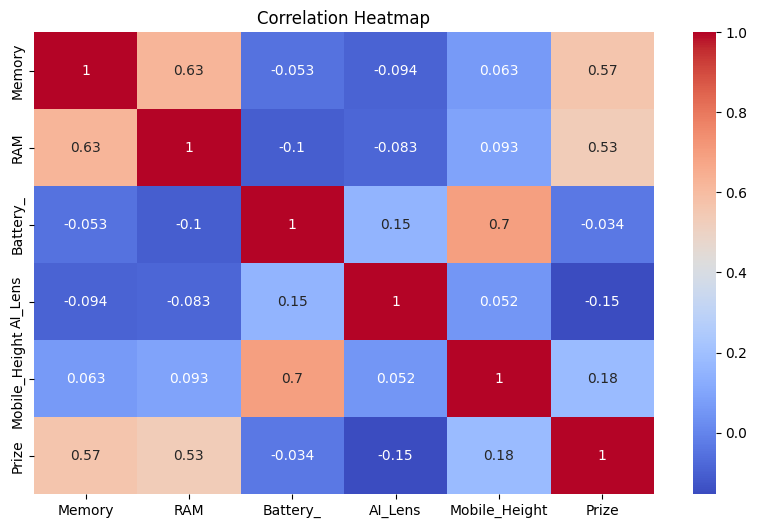

In [ ]:
#Correlation heatmap (to see relationships with price)
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#Data Preprocessing
print(df.isnull().sum())


Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear_Camera      0
Front_Camera     0
AI_Lens          0
Mobile_Height    0
Processor_       0
Prize            0
dtype: int64


In [ ]:
print(df.columns.tolist())

['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear_Camera', 'Front_Camera', 'AI_Lens', 'Mobile_Height', 'Processor_', 'Prize']


In [ ]:
if 'AI Lens' in df.columns:
    df['AI Lens'] = df['AI Lens'].map({'Yes':1, 'No':0})
else:
    print("Column 'AI Lens' not found. Available columns:", df.columns.tolist())

Column 'AI Lens' not found. Available columns: ['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear_Camera', 'Front_Camera', 'AI_Lens', 'Mobile_Height', 'Processor_', 'Prize']


In [ ]:
# Fill numerical missing values with median
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
for col in df.select_dtypes(include=['int64','float64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df[col] = df[col].clip(lower, upper)

In [ ]:
['Model', 'Colour', 'Processor_', 'AI_Lens', 'RAM', 'Internal Memory', 'Battery', 'Rear Camera', 'Front Camera', 'Height', 'Prize']

['Model',
 'Colour',
 'Processor_',
 'AI_Lens',
 'RAM',
 'Internal Memory',
 'Battery',
 'Rear Camera',
 'Front Camera',
 'Height',
 'Prize']

In [ ]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("DataFrame shape after one-hot encoding:", df.shape)
print("First 5 rows after one-hot encoding:")
print(df.head())

DataFrame shape after one-hot encoding: (541, 613)
First 5 rows after one-hot encoding:
   Memory  RAM  Battery_  AI_Lens  Mobile_Height  Prize  \
0      64    4      5000        0          16.76   7299   
1      64    4      5000        0          16.76   7299   
2     128    8      5000        0          16.64  11999   
3      32    2      5000        0          16.56   5649   
4     128    8      5000        0          16.76   8999   

   Model_APPLE iPhone 12  Model_APPLE iPhone 14 Plus  Model_Google Pixel 6a  \
0                  False                       False                  False   
1                  False                       False                  False   
2                  False                       False                  False   
3                  False                       False                  False   
4                  False                       False                  False   

   Model_Google Pixel 7  ...  Processor__Unisoc Spreadtrum SC9863A1  \
0          

In [ ]:
# Detect categorical columns automatically
categorical_cols_current = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns for One-Hot Encoding:", categorical_cols_current)

# Apply one-hot encoding safely
df = pd.get_dummies(df, columns=categorical_cols_current, drop_first=True)

Categorical Columns for One-Hot Encoding: ['Model', 'Colour', 'Rear_Camera', 'Front_Camera', 'Processor_']


In [ ]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
print(df.columns.tolist())

['Memory', 'RAM', 'Battery_', 'AI_Lens', 'Mobile_Height', 'Prize', 'Model_APPLE_iPhone_12', 'Model_APPLE_iPhone_14_Plus', 'Model_Google_Pixel_6a', 'Model_Google_Pixel_7', 'Model_Google_Pixel_7a', 'Model_I_Kall_Z19Pro', 'Model_I_Kall_Z19Pro_Flash_blue', 'Model_IQOO_Neo_7_5G', 'Model_Infinix_HOT_12_Play', 'Model_Infinix_HOT_20_5G', 'Model_Infinix_HOT_20_Play', 'Model_Infinix_HOT_30i', 'Model_Infinix_Hot_11', 'Model_Infinix_Hot_12', 'Model_Infinix_Hot_12_Pro', 'Model_Infinix_Hot_20_5G', 'Model_Infinix_NOTE_12i', 'Model_Infinix_Note_11s_Free_Fire_Edition', 'Model_Infinix_Note_12', 'Model_Infinix_Note_12_5G', 'Model_Infinix_Note_12_Pro', 'Model_Infinix_Note_12_Pro_5G', 'Model_Infinix_SMART_7', 'Model_Infinix_Smart_5A', 'Model_Infinix_Smart_6', 'Model_Infinix_Smart_6_HD', 'Model_Infinix_Smart_7_HD', 'Model_Infinix_Zero_20', 'Model_Infinix_Zero_5G_2023', 'Model_Infinix_Zero_5G_2023_TURBO', 'Model_LAVA_Z2', 'Model_LAVA_Z21', 'Model_MOTOROLA_Edge_30', 'Model_MOTOROLA_Edge_30_Fusion', 'Model_MOT

In [ ]:
print("Dataset shape after preprocessing:", df.shape)

Dataset shape after preprocessing: (541, 613)


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split




In [ ]:

# Strip spaces and replace with underscores for consistency
df.columns = df.columns.str.strip().str.replace(" ", "_")
print("Cleaned Columns:", df.columns.tolist())

Cleaned Columns: ['Memory', 'RAM', 'Battery_', 'AI_Lens', 'Mobile_Height', 'Prize', 'Model_APPLE_iPhone_12', 'Model_APPLE_iPhone_14_Plus', 'Model_Google_Pixel_6a', 'Model_Google_Pixel_7', 'Model_Google_Pixel_7a', 'Model_I_Kall_Z19Pro', 'Model_I_Kall_Z19Pro_Flash_blue', 'Model_IQOO_Neo_7_5G', 'Model_Infinix_HOT_12_Play', 'Model_Infinix_HOT_20_5G', 'Model_Infinix_HOT_20_Play', 'Model_Infinix_HOT_30i', 'Model_Infinix_Hot_11', 'Model_Infinix_Hot_12', 'Model_Infinix_Hot_12_Pro', 'Model_Infinix_Hot_20_5G', 'Model_Infinix_NOTE_12i', 'Model_Infinix_Note_11s_Free_Fire_Edition', 'Model_Infinix_Note_12', 'Model_Infinix_Note_12_5G', 'Model_Infinix_Note_12_Pro', 'Model_Infinix_Note_12_Pro_5G', 'Model_Infinix_SMART_7', 'Model_Infinix_Smart_5A', 'Model_Infinix_Smart_6', 'Model_Infinix_Smart_6_HD', 'Model_Infinix_Smart_7_HD', 'Model_Infinix_Zero_20', 'Model_Infinix_Zero_5G_2023', 'Model_Infinix_Zero_5G_2023_TURBO', 'Model_LAVA_Z2', 'Model_LAVA_Z21', 'Model_MOTOROLA_Edge_30', 'Model_MOTOROLA_Edge_30_Fu

In [ ]:
#Handle missing values ---
# Fill numerical missing values with median
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Prize'])
y = df['Prize']

# Re-identify numerical columns in X (features only)
features_numerical_cols = X.select_dtypes(include=['int64', 'float64', 'uint8', 'bool']).columns.tolist()

scaler = StandardScaler()
X[features_numerical_cols] = scaler.fit_transform(X[features_numerical_cols])

print("Scaled features (first 5 rows):")
print(X.head())

Scaled features (first 5 rows):
     Memory       RAM  Battery_  AI_Lens  Mobile_Height  \
0 -0.816382 -0.704665       0.0      0.0       0.266153   
1 -0.816382 -0.704665       0.0      0.0       0.266153   
2  0.390346  1.312392       0.0      0.0      -0.113473   
3 -1.419746 -1.713193       0.0      0.0      -0.366556   
4  0.390346  1.312392       0.0      0.0       0.266153   

   Model_APPLE iPhone 12  Model_APPLE iPhone 14 Plus  Model_Google Pixel 6a  \
0              -0.043033                   -0.074674              -0.074674   
1              -0.043033                   -0.074674              -0.074674   
2              -0.043033                   -0.074674              -0.074674   
3              -0.043033                   -0.074674              -0.074674   
4              -0.043033                   -0.074674              -0.074674   

   Model_Google Pixel 7  Model_Google Pixel 7a  ...  \
0             -0.074674              -0.074674  ...   
1             -0.074674     

In [ ]:

# Fill categorical missing values with mode
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
# Train-Test Split
# Check actual target column name
print("Available Columns:", df.columns.tolist())

In [ ]:

# Replace 'Price' with the actual target column name after cleaning
target_col = 'Price' if 'Price' in df.columns else 'Prize'  # adjust if needed


In [ ]:
target_col = 'Prize'

In [ ]:
print("After encoding:", df.shape)


In [ ]:
df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("RandomForestRegressor and evaluation metrics imported successfully.")

In [ ]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("RandomForestRegressor model trained and predictions made.")

In [ ]:
# Re-create X_train and X_test from the original scaled X, y to get the version without engineered features
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(X, y, test_size=0.2, random_state=42)

new_predictions = loaded_model.predict(X_test_original)

print("Predictions using the loaded model on X_test (first 5):")
print(new_predictions[:5])

In [ ]:
import joblib

# Load the saved model
loaded_model = joblib.load('tuned_random_forest_model.joblib')

print("Tuned model loaded successfully.")
# You can now use loaded_model to make predictions
# For example: new_predictions = loaded_model.predict(new_data)

In [ ]:
import joblib

# Save the tuned model
joblib.dump(best_model, 'tuned_random_forest_model.joblib')
print("Tuned model saved successfully as 'tuned_random_forest_model.joblib'")

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Prize')
plt.ylabel('Predicted Prize')
plt.title('Actual vs. Predicted Prize Values')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

print("RandomizedSearchCV imported successfully.")

In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
    'max_features': ['sqrt', 'log2', 0.6, 0.8, 1.0],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Hyperparameter search space defined:")
print(param_dist)

Hyperparameter search space defined:
{'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000], 'max_features': ['sqrt', 'log2', 0.6, 0.8, 1.0], 'max_depth': [10, 20, 30, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

model_rfr = RandomForestRegressor(random_state=42)
rscv = RandomizedSearchCV(estimator=model_rfr, param_distributions=param_dist, n_iter=100, cv=5, verbose=2, random_state=42, n_jobs=-1, scoring='neg_mean_squared_error')
rscv.fit(X_train, y_train);

print("RandomizedSearchCV completed.")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
RandomizedSearchCV completed.


In [ ]:
print("Best parameters found:", rscv.best_params_)
print("Best negative MSE score:", rscv.best_score_)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_model = rscv.best_estimator_
y_pred_tuned = best_model.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned Model - Mean Absolute Error (MAE): {mae_tuned:.2f}")
print(f"Tuned Model - Mean Squared Error (MSE): {mse_tuned:.2f}")
print(f"Tuned Model - R-squared (R2): {r2_tuned:.2f}")

Tuned Model - Mean Absolute Error (MAE): 1580.14
Tuned Model - Mean Squared Error (MSE): 8222195.73
Tuned Model - R-squared (R2): 0.86


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_tuned, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Prize')
plt.ylabel('Predicted Prize (Tuned Model)')
plt.title('Actual vs. Predicted Prize Values (Tuned Model)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_tuned, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Prize')
plt.ylabel('Predicted Prize (Tuned Model)')
plt.title('Actual vs. Predicted Prize Values (Tuned Model)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("--- Features DataFrame (X) Info ---")
X.info()

print("\n--- Features DataFrame (X) Descriptive Statistics ---")
print(X.describe())

--- Features DataFrame (X) Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Columns: 612 entries, Memory to Processor__snapdragon 888
dtypes: float64(612)
memory usage: 2.5 MB

--- Features DataFrame (X) Descriptive Statistics ---
             Memory         RAM  Battery_  AI_Lens  Mobile_Height  \
count  5.410000e+02  541.000000     541.0    541.0   5.410000e+02   
mean   1.247718e-16    0.000000       0.0      0.0  -1.359356e-14   
std    1.000925e+00    1.000925       0.0      0.0   1.000925e+00   
min   -1.721428e+00   -1.713193       0.0      0.0  -2.565222e+00   
25%   -8.163816e-01   -0.704665       0.0      0.0  -5.247336e-01   
50%    3.903464e-01    0.303863       0.0      0.0   1.079758e-01   
75%    3.903464e-01    1.312392       0.0      0.0   8.355916e-01   
max    2.200438e+00    1.312392       0.0      0.0   2.876079e+00   

       Model_APPLE iPhone 12  Model_APPLE iPhone 14 Plus  \
count             541.000000                  541.00000

Top 20 Feature Importances:
                                           Feature  Importance
0                                           Memory    0.084895
1                                              RAM    0.074388
612                         RAM_Memory_Interaction    0.062267
614                                    RAM_Squared    0.051132
613                                 Memory_per_RAM    0.048127
487                               Front_Camera_5MP    0.042954
4                                    Mobile_Height    0.041683
484                              Front_Camera_32MP    0.033641
481                              Front_Camera_16MP    0.028454
476                               Rear_Camera_64MP    0.020506
477                                Rear_Camera_8MP    0.016373
466                               Rear_Camera_12MP    0.014824
588                             Processor__SC6531E    0.014764
467                               Rear_Camera_13MP    0.010046
489                        

/tmp/ipython-input-351/2955597165.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(20), palette='viridis')


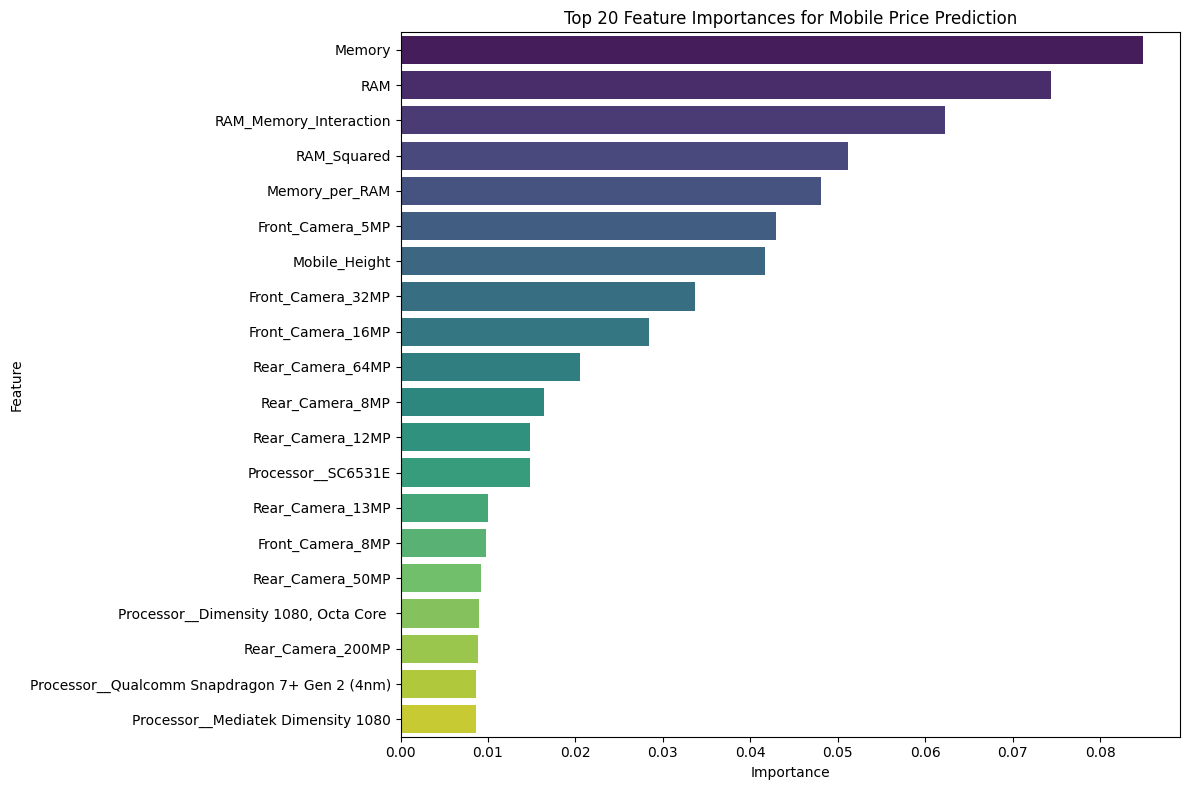

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# Define and fit the best-tuned model with new features
best_model_new_features = RandomForestRegressor(random_state=42, **rscv.best_params_)
best_model_new_features.fit(X_train, y_train)

# Get feature importances from the best-tuned model with new features
feature_importances = best_model_new_features.feature_importances_

# Create a pandas Series for better handling and sorting
features_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display the top 20 most important features
print("Top 20 Feature Importances:")
print(features_df.head(20))

# Visualize top N feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances for Mobile Price Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Target Series (y) Info ---")
y.info()

print("\n--- Target Series (y) Descriptive Statistics ---")
print(y.describe())

In [ ]:
epsilon = 1e-6

# 1. Create 'RAM_Memory_Interaction'
X_train['RAM_Memory_Interaction'] = X_train['RAM'] * X_train['Memory']
X_test['RAM_Memory_Interaction'] = X_test['RAM'] * X_test['Memory']

# 2. Create 'Memory_per_RAM'
X_train['Memory_per_RAM'] = X_train['Memory'] / (X_train['RAM'] + epsilon)
X_test['Memory_per_RAM'] = X_test['Memory'] / (X_test['RAM'] + epsilon)

# 3. Create 'RAM_Squared'
X_train['RAM_Squared'] = X_train['RAM']**2
X_test['RAM_Squared'] = X_test['RAM']**2

print("X_train with new features (head):")
print(X_train.head())
print("\nX_test with new features (head):")
print(X_test.head())

In [ ]:
epsilon = 1e-6

# Calculate new features for X_train
X_train_new_features = pd.DataFrame({
    'RAM_Memory_Interaction': X_train['RAM'] * X_train['Memory'],
    'Memory_per_RAM': X_train['Memory'] / (X_train['RAM'] + epsilon),
    'RAM_Squared': X_train['RAM']**2
}, index=X_train.index)

# Concatenate new features to X_train
X_train = pd.concat([X_train, X_train_new_features], axis=1)

# Calculate new features for X_test
X_test_new_features = pd.DataFrame({
    'RAM_Memory_Interaction': X_test['RAM'] * X_test['Memory'],
    'Memory_per_RAM': X_test['Memory'] / (X_test['RAM'] + epsilon),
    'RAM_Squared': X_test['RAM']**2
}, index=X_test.index)

# Concatenate new features to X_test
X_test = pd.concat([X_test, X_test_new_features], axis=1)

print("X_train with new features (head):")
print(X_train.head())
print("\nX_test with new features (head):")
print(X_test.head())


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd # Ensure pandas is imported for DataFrame operations

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

epsilon = 1e-6

# Calculate new features for X_train
X_train_new_features = pd.DataFrame({
    'RAM_Memory_Interaction': X_train['RAM'] * X_train['Memory'],
    'Memory_per_RAM': X_train['Memory'] / (X_train['RAM'] + epsilon),
    'RAM_Squared': X_train['RAM']**2
}, index=X_train.index)

# Concatenate new features to X_train
X_train = pd.concat([X_train, X_train_new_features], axis=1)

# Calculate new features for X_test
X_test_new_features = pd.DataFrame({
    'RAM_Memory_Interaction': X_test['RAM'] * X_test['Memory'],
    'Memory_per_RAM': X_test['Memory'] / (X_test['RAM'] + epsilon),
    'RAM_Squared': X_test['RAM']**2
}, index=X_test.index)

# Concatenate new features to X_test
X_test = pd.concat([X_test, X_test_new_features], axis=1)

print("Shape of X_train after feature engineering:", X_train.shape)
print("X_train with new features (head):")
print(X_train.head())
print("\nShape of X_test after feature engineering:", X_test.shape)
print("X_test with new features (head):")
print(X_test.head())

Shape of X_train after feature engineering: (432, 615)
X_train with new features (head):
       Memory       RAM  Battery_  AI_Lens  Mobile_Height  \
244 -1.721428  1.312392       0.0      0.0      -2.565222   
540  0.390346 -0.704665       0.0      0.0      -0.050202   
417  0.390346  1.312392       0.0      0.0      -2.138143   
509  0.390346  0.303863       0.0      0.0       0.266153   
353 -0.816382 -0.704665       0.0      0.0      -0.050202   

     Model_APPLE iPhone 12  Model_APPLE iPhone 14 Plus  Model_Google Pixel 6a  \
244              -0.043033                   -0.074674              -0.074674   
540              -0.043033                   -0.074674              -0.074674   
417              -0.043033                   -0.074674              -0.074674   
509              -0.043033                   -0.074674              -0.074674   
353              -0.043033                   -0.074674              -0.074674   

     Model_Google Pixel 7  Model_Google Pixel 7a  ...  Pr

In [ ]:
# This code has been moved to cell 55dbae08 to ensure correct execution order.
# The model is now defined and fitted before feature importances are accessed.

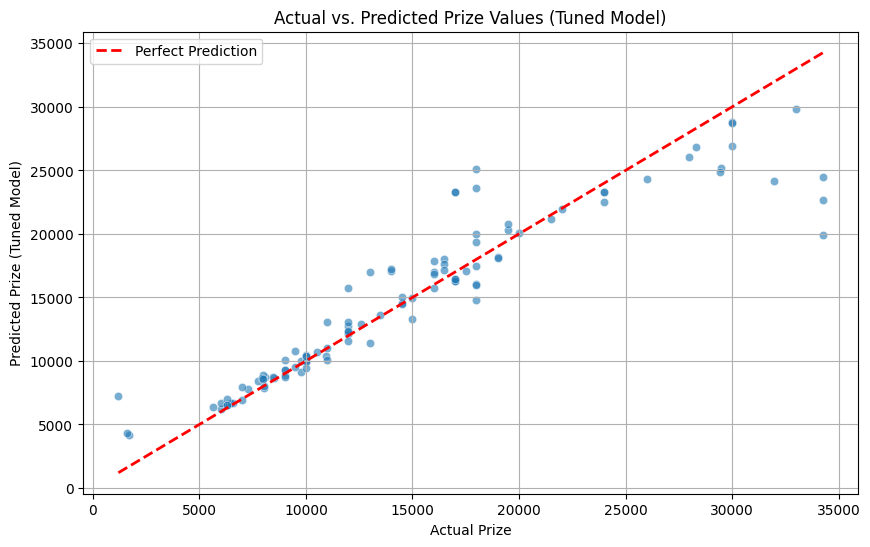

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_tuned, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Prize')
plt.ylabel('Predicted Prize (Tuned Model)')
plt.title('Actual vs. Predicted Prize Values (Tuned Model)')
plt.legend()
plt.grid(True)
plt.show()